In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [52]:
DATA_DIR_REAL = '/info/etu/m2/s2405959/deepLearning/L3_project/fox_in_snow_real'
DATA_DIR_AUG = '/info/etu/m2/s2405959/deepLearning/L3_project/fox_in_snow_generated'
IMG_SIZE = 128
BATCH_SIZE = 16
LATENT_DIM = 100

class FoxSnowDataset(Dataset):
    def __init__(self, data_dirs, img_size=128):
        self.img_size = img_size
        self.image_paths = []
        for data_dir in data_dirs:
            if os.path.exists(data_dir):
                for file in os.listdir(data_dir):
                    if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.image_paths.append(os.path.join(data_dir, file))
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img)

dataset = FoxSnowDataset([DATA_DIR_REAL, DATA_DIR_AUG], img_size=IMG_SIZE)
NUM_IMAGES = len(dataset)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
print(f"Dataset: {NUM_IMAGES} images | Batch size: {BATCH_SIZE}")

Dataset: 500 images | Batch size: 16


In [ ]:
class SamePadConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, **kwargs):
        super().__init__()
        self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else kernel_size
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=0, **kwargs)
    def forward(self, x):
        kh, kw = self.kernel_size
        pad_h = kh - 1
        pad_w = kw - 1
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), mode='reflect')
        return self.conv(x)

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        n_nodes = 128 * 32 * 32
        self.project = nn.Sequential(
            nn.Linear(latent_dim, n_nodes),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.reshape_shape = (128, 32, 32)
        self.features = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            SamePadConv2d(128, 128, kernel_size=4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2, mode='nearest'),
            SamePadConv2d(128, 128, kernel_size=4),
            nn.LeakyReLU(0.2, inplace=True),

            SamePadConv2d(128, 3, kernel_size=32),
            nn.Sigmoid()
        )
    def forward(self, z):
        x = self.project(z)
        x = x.view(z.size(0), *self.reshape_shape)
        return self.features(x)


In [54]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            nn.Flatten(),
            nn.Linear(256 * 16 * 16, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [55]:
generator = Generator(LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

In [ ]:
CHECKPOINT_DIR = '/info/etu/m2/s2405959/deepLearning/L3_project/GANs_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.001, betas=(0.75, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

def toggle_grad(model, requires_grad):
    for param in model.parameters():
        param.requires_grad = requires_grad

def generate_latent_points(latent_dim, nb_images):
    return torch.randn(nb_images, latent_dim, device=device)

def generate_fake_samples(nb_images):
    with torch.no_grad():
        z = generate_latent_points(LATENT_DIM, nb_images)
        fake_images = generator(z)
    fake_labels = torch.zeros((nb_images, 1), device=device)
    return fake_images.detach(), fake_labels

def generate_fake_samples_for_generator(nb_images):
    z = generate_latent_points(LATENT_DIM, nb_images)
    fake_images = generator(z)
    fake_labels = torch.ones((nb_images, 1), device=device)
    return fake_images, fake_labels

def visualize_grid(images, num_images=10, cols=5):
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    if rows == 1:
        axes = axes.reshape(1, -1)
    images_np = images.detach().cpu().numpy()
    for i in range(num_images):
        row, col = i // cols, i % cols
        ax = axes[row, col]
        img = np.transpose(images_np[i], (1, 2, 0))
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis('off')
    for i in range(num_images, rows * cols):
        row, col = i // cols, i % cols
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

def evaluate_model(epoch, model_name, nb_images=50, should_plot=False):
    generator.eval()
    discriminator.eval()
    
    with torch.no_grad():
        try:
            real_imgs = next(iter(dataloader))
        except StopIteration:
            real_imgs = next(iter(dataloader))
        real_imgs = real_imgs[:nb_images].to(device)
        real_labels = torch.ones((real_imgs.size(0), 1), device=device)
        
        z = generate_latent_points(LATENT_DIM, nb_images)
        fake_imgs = generator(z)
        fake_labels = torch.zeros((nb_images, 1), device=device)
        
        real_pred = discriminator(real_imgs)
        fake_pred = discriminator(fake_imgs)
        
        acc_real = ((real_pred > 0.5).float().sum() / real_imgs.size(0)).item()
        acc_fake = ((fake_pred < 0.5).float().sum() / nb_images).item()
        
        val_d_loss_real = adversarial_loss(real_pred, real_labels).item()
        val_d_loss_fake = adversarial_loss(fake_pred, fake_labels).item()
        val_d_loss = (val_d_loss_real + val_d_loss_fake) / 2
        
        gan_labels = torch.ones((nb_images, 1), device=device)
        val_g_loss = adversarial_loss(fake_pred, gan_labels).item()
        
        if should_plot:
            visualize_grid(fake_imgs, num_images=min(25, nb_images), cols=5)
    
    gen_path = os.path.join(CHECKPOINT_DIR, f"{model_name}generator_{epoch:04d}.pth")
    disc_path = os.path.join(CHECKPOINT_DIR, f"{model_name}discriminator_{epoch:04d}.pth")
    torch.save(generator.state_dict(), gen_path)
    torch.save(discriminator.state_dict(), disc_path)
    print(f"Saved generator to {gen_path}")
    print(f"Saved discriminator to {disc_path}")
    print(f"Val D loss: {val_d_loss:.4f} | Val G loss: {val_g_loss:.4f} | Acc real: {acc_real*100:.1f}% | Acc fake: {acc_fake*100:.1f}%")
    
    generator.train()
    discriminator.train()
    
    return acc_real, acc_fake, val_d_loss, val_g_loss


In [ ]:
def train_gan(num_epochs=200, batchsize=BATCH_SIZE, evaluate_period=50, model_name=None, initial_epoch=0, sample_plot=True, log_every_batches=None):
    if model_name is None:
        model_name = f"arthur_Z{LATENT_DIM}_BS{batchsize}_"
    if batchsize != BATCH_SIZE:
        print("[warning] train_gan batchsize differs from dataloader batch size; recreate dataloader if needed.")
    batches_per_epoch = len(dataloader)
    if batches_per_epoch == 0:
        raise ValueError("Dataloader is empty. Verify dataset paths.")
    half_batch = batchsize // 2
    history = {"g_loss": [], "d_loss": [], "acc_real": [], "acc_fake": [], "val_d_loss": [], "val_g_loss": []}
    data_iter = iter(dataloader)
    log_interval = log_every_batches or max(1, batches_per_epoch // 4)
    
    for epoch in range(initial_epoch, initial_epoch + num_epochs):
        epoch_idx = epoch - initial_epoch + 1
        print(f"\n=== Epoch {epoch_idx}/{num_epochs} ===")
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        
        for batch_idx in range(batches_per_epoch):
            try:
                real_imgs = next(data_iter)
            except StopIteration:
                data_iter = iter(dataloader)
                real_imgs = next(data_iter)
            real_imgs = real_imgs[:half_batch].to(device)
            
            fake_imgs, _ = generate_fake_samples(half_batch)
            
            real_labels = torch.ones((half_batch, 1), device=device)
            fake_labels = torch.zeros((half_batch, 1), device=device)
            disc_inputs = torch.cat([real_imgs, fake_imgs], dim=0)
            disc_targets = torch.cat([real_labels, fake_labels], dim=0)
            
            discriminator.train()
            optimizer_D.zero_grad()
            d_pred = discriminator(disc_inputs)
            d_loss = adversarial_loss(d_pred, disc_targets)
            d_loss.backward()
            optimizer_D.step()
            epoch_d_loss += d_loss.item()

            toggle_grad(discriminator, False)
            optimizer_G.zero_grad()
            gan_imgs, gan_targets = generate_fake_samples_for_generator(batchsize)
            g_pred = discriminator(gan_imgs)
            g_loss = adversarial_loss(g_pred, gan_targets)
            g_loss.backward()
            optimizer_G.step()
            toggle_grad(discriminator, True)
            epoch_g_loss += g_loss.item()

            if (batch_idx + 1) % log_interval == 0 or batch_idx == 0 or batch_idx + 1 == batches_per_epoch:
                print(f"Batch {batch_idx + 1}/{batches_per_epoch} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

        epoch_g_loss /= batches_per_epoch
        epoch_d_loss /= batches_per_epoch
        history["g_loss"].append(epoch_g_loss)
        history["d_loss"].append(epoch_d_loss)
        print(f"Epoch {epoch_idx}/{num_epochs} | batches {batches_per_epoch} | Train D loss: {epoch_d_loss:.4f} | Train G loss: {epoch_g_loss:.4f}")

        if epoch == initial_epoch or epoch_idx % evaluate_period == 0:
            acc_real, acc_fake, val_d_loss, val_g_loss = evaluate_model(epoch_idx, model_name, nb_images=50, should_plot=sample_plot)
            history["acc_real"].append(acc_real)
            history["acc_fake"].append(acc_fake)
            history["val_d_loss"].append(val_d_loss)
            history["val_g_loss"].append(val_g_loss)

    return history



=== Epoch 1/1 ===


Batch 1/31 | D loss: 0.6933 | G loss: 0.5740
Batch 2/31 | D loss: 0.7099 | G loss: 0.4937
Batch 2/31 | D loss: 0.7099 | G loss: 0.4937
Batch 4/31 | D loss: 0.6827 | G loss: 0.5428
Batch 4/31 | D loss: 0.6827 | G loss: 0.5428
Batch 6/31 | D loss: 0.6728 | G loss: 0.5551
Batch 6/31 | D loss: 0.6728 | G loss: 0.5551
Batch 8/31 | D loss: 0.6793 | G loss: 0.5135
Batch 8/31 | D loss: 0.6793 | G loss: 0.5135
Batch 10/31 | D loss: 0.6431 | G loss: 0.5808
Batch 10/31 | D loss: 0.6431 | G loss: 0.5808
Batch 12/31 | D loss: 0.6248 | G loss: 0.5049
Batch 12/31 | D loss: 0.6248 | G loss: 0.5049
Batch 14/31 | D loss: 0.6250 | G loss: 0.6448
Batch 14/31 | D loss: 0.6250 | G loss: 0.6448
Batch 16/31 | D loss: 0.5990 | G loss: 0.4206
Batch 16/31 | D loss: 0.5990 | G loss: 0.4206
Batch 18/31 | D loss: 0.5582 | G loss: 0.8378
Batch 18/31 | D loss: 0.5582 | G loss: 0.8378
Batch 20/31 | D loss: 0.6534 | G loss: 1.0904
Batch 20/31 | D loss: 0.6534 | G loss: 1.0904
Batch 22/31 | D loss: 0.5561 | G loss: 0.64

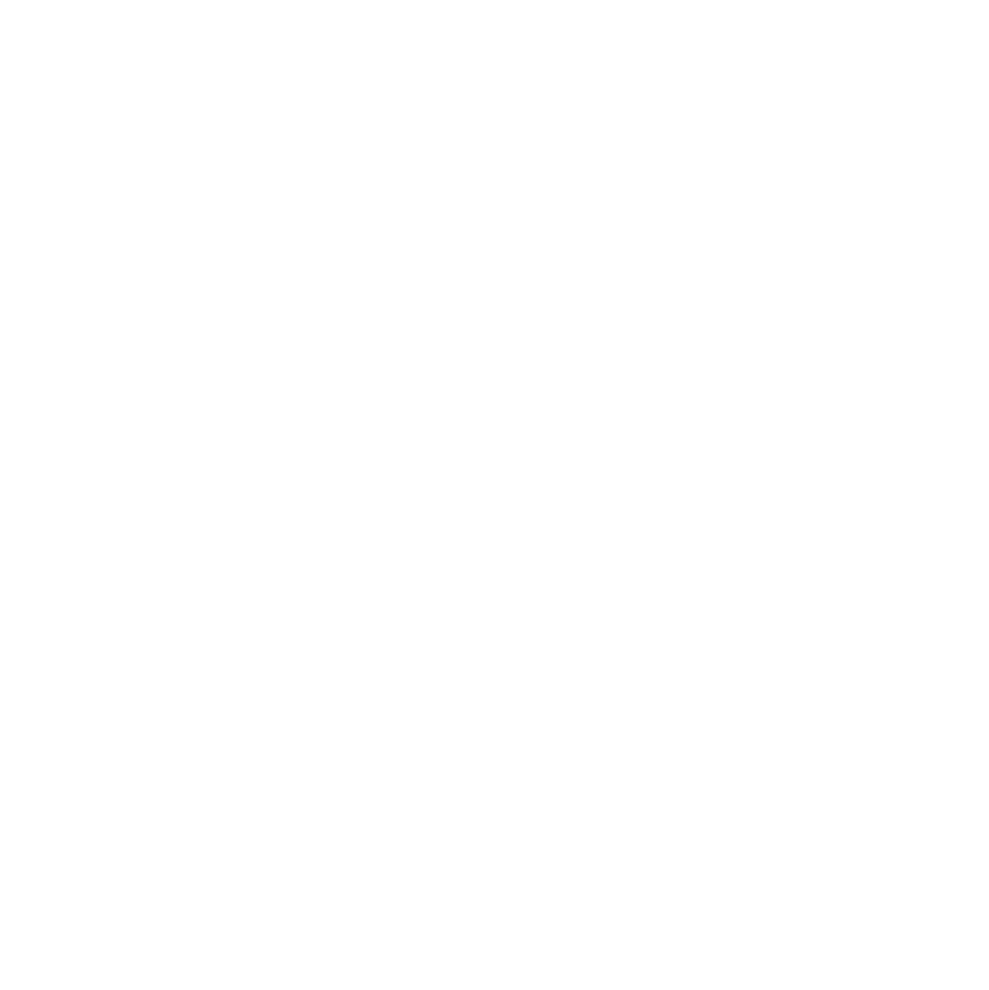

Saved generator to /info/etu/m2/s2405959/deepLearning/L3_project/GANs_checkpoints/Z100_BS16_testRun_generator_0001.pth
Saved discriminator to /info/etu/m2/s2405959/deepLearning/L3_project/GANs_checkpoints/Z100_BS16_testRun_discriminator_0001.pth
Val D loss: 0.2812 | Val G loss: 1.2118 | Acc real: 100.0% | Acc fake: 100.0%


In [ ]:
RUN_EPOCHS = 1
MODEL_NAME = "Z100_BS16_testRun_"
EVAL_PERIOD = 5
history_cpu = train_gan(num_epochs=RUN_EPOCHS, batchsize=BATCH_SIZE, evaluate_period=EVAL_PERIOD, model_name=MODEL_NAME, sample_plot=True, log_every_batches=2)


In [59]:
def generate_latent_points(latent_dim, nb_images):
    return torch.randn(nb_images, latent_dim, device=device)

def generate(model, nb_images=10, latent_dim=100, cols=5, show=True):
    model.eval()
    with torch.no_grad():
        z = generate_latent_points(latent_dim, nb_images)
        generated_images = model(z)
    if show:
        visualize_grid(generated_images, num_images=nb_images, cols=cols)
    model.train()
    return generated_images.detach().cpu()

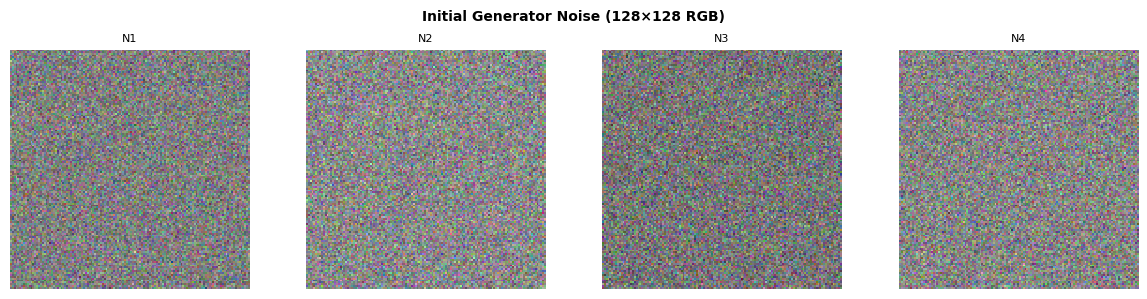

In [ ]:
LATENT_DIM = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def generate_latent_points(latent_dim, nb_images):
    return torch.randn(nb_images, latent_dim, device=device)

noise_size = 128
rgb_channels = 3
num_samples = 4

fig, axes = plt.subplots(1, num_samples, figsize=(12, 3))
fig.suptitle('Initial Generator Noise (128×128 RGB)', fontsize=10, fontweight='bold')

for idx, axis in enumerate(axes):
    noise_rgb = np.random.randn(noise_size, noise_size, rgb_channels)
    
    noise_rgb = (noise_rgb - noise_rgb.min()) / (noise_rgb.max() - noise_rgb.min() + 1e-8)
    
    axis.imshow(noise_rgb, interpolation='nearest')
    axis.axis('off')
    axis.set_title(f'N{idx + 1}', fontsize=8)

plt.tight_layout()
plt.show()
